# Demography Analysis

In this notebook, we analyze user demographics such as age and gender, and explore how these factors influence average ratings given by users. We will extract profile data from a PostgreSQL database, clean and process the data using Pandas, and perform a federated query with DuckDB to join this data with ratings stored in a Parquet file. Finally, we will visualize the results using Seaborn and Matplotlib.

### 1. Import libraries

In [1]:
import duckdb
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import lib.dbconnection as dbc

sns.set_theme(style="whitegrid")

### 2. Create DB engine

In [2]:
engine = dbc.create_db_engine()
print("Caricamento profili dal DB Postgres...")

Caricamento profili dal DB Postgres...


---

### 3. Load and clean profile data from PostgreSQL

In [3]:
query_profiles = "SELECT username, gender, birthday FROM profiles"
df_profiles_raw = pd.read_sql(query_profiles, engine)

### Cleaning data (DA FARE SU CLEANING)

In [4]:
df_profiles_raw['birthday_dt'] = pd.to_datetime(df_profiles_raw['birthday'], errors='coerce')

df_profiles_raw['birth_year'] = df_profiles_raw['birthday_dt'].dt.year
df_profiles_raw['age'] = 2025 - df_profiles_raw['birth_year']

df_profiles_clean = df_profiles_raw.dropna(subset=['age', 'gender'])
df_profiles_clean = df_profiles_clean[df_profiles_clean['gender'] != '']

print(f"Profili validi pronti per l'analisi: {len(df_profiles_clean)}")
print(df_profiles_clean[['username', 'age', 'gender']].head())

Profili validi pronti per l'analisi: 79299
       username   age  gender
15       RinsAl  36.0    Male
19     ishimori  25.0  Female
25        Rins_  37.0    Male
29  FollowValen  29.0    Male
30   ishiruchan  22.0  Female


In [5]:
PARQUET_PATH = '../../../cleaned_data/ratings_cleaned.parquet'

query = f"""
SELECT
    p.age,
    p.gender,
    AVG(r.score) as avg_score
FROM read_parquet('{PARQUET_PATH}') r
JOIN df_profiles_clean p ON r.username = p.username
WHERE
    r.score > 0
    AND p.age BETWEEN 10 AND 80
GROUP BY p.age, p.gender
ORDER BY p.age;
"""

print("Esecuzione Join tra DataFrame (RAM) e Parquet (Disco)...")
df_agg = duckdb.sql(query).df()

print(f"Risultato aggregazione: {len(df_agg)} righe.")
print(df_agg.head())

Esecuzione Join tra DataFrame (RAM) e Parquet (Disco)...
Risultato aggregazione: 174 righe.
    age      gender  avg_score
0  10.0      Female   7.394286
1  10.0        Male   7.040698
2  11.0      Female   6.309645
3  11.0  Non-Binary   6.534091
4  11.0        Male   5.464589


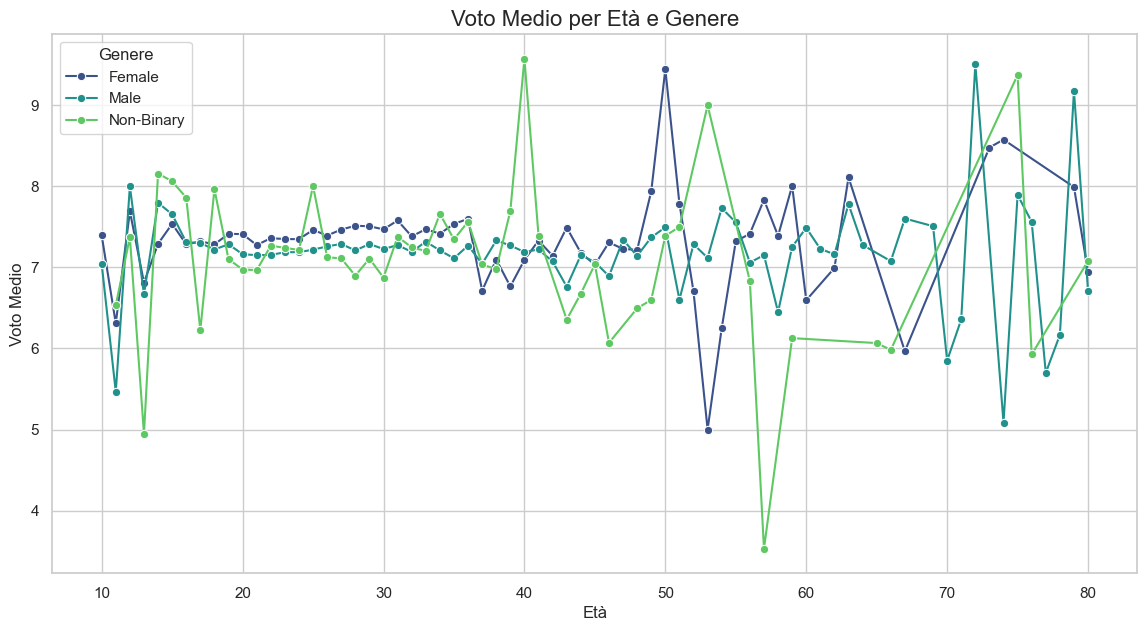

In [6]:
if not df_agg.empty:
    plt.figure(figsize=(14, 7))
    sns.lineplot(
        data=df_agg,
        x='age',
        y='avg_score',
        hue='gender',
        palette="viridis",
        marker='o'
    )
    plt.title('Voto Medio per Età e Genere', fontsize=16)
    plt.xlabel('Età')
    plt.ylabel('Voto Medio')
    plt.legend(title='Genere')
    plt.savefig('../../graphs/ranksByYearsAndGenre.png', dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("ERRORE: Il DataFrame è vuoto. Verifica che i nomi utente coincidano tra DB e Parquet.")

